## Build Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              roc_curve, roc_auc_score)

np.random.seed(42)
n = 1000

df = pd.DataFrame({
    'study_hours'   : np.random.normal(6, 2, n).clip(0, 12),
    'sleep_hours'   : np.random.normal(7, 1.5, n).clip(3, 10),
    'attendance_pct': np.random.normal(75, 15, n).clip(0, 100),
    'prev_score'    : np.random.normal(65, 15, n).clip(0, 100),
    'stress_level'  : np.random.randint(1, 10, n).astype(float),
    'exercise_days' : np.random.randint(0, 7, n).astype(float),
})

score = (
    df['study_hours']    * 4.0 +
    df['attendance_pct'] * 0.3 +
    df['prev_score']     * 0.4 +
    df['sleep_hours']    * 1.5 +
    np.random.normal(0, 5, n)
)
df['result'] = (score > score.median()).astype(int)

X = df.drop('result', axis=1)
y = df['result']
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Step 1 — Scale Features


In [2]:
scaler   = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
# ↑ fit ONLY on train, transform both
#   prevents data leakage from test set
#   scaling is CRITICAL for logistic regression
#   unscaled features → weights not comparable
#   gradient descent also converges much faster when scaled

## Step 2 — Train Model

In [3]:
lr = LogisticRegression(
    penalty      = 'l2',
    # ↑ regularization type: 'l1', 'l2', 'elasticnet', None

    C            = 1.0,
    # ↑ inverse regularization strength
    #   smaller C = stronger regularization

    solver       = 'lbfgs',
    # ↑ optimization algorithm
    #   lbfgs  → good default for small/medium data
    #   saga   → good for large data + L1
    #   liblinear → good for small data + L1

    max_iter     = 1000,
    # ↑ maximum iterations for solver to converge
    #   increase if you get ConvergenceWarning

    random_state = 42
)

lr.fit(X_train_scaled, y_train)

y_pred      = lr.predict(X_test_scaled)
y_pred_prob = lr.predict_proba(X_test_scaled)[:, 1]
# ↑ probability of class 1 (Pass) for each sample

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Fail', 'Pass']))

Accuracy: 0.875

Classification Report:
              precision    recall  f1-score   support

        Fail       0.88      0.87      0.88       102
        Pass       0.87      0.88      0.87        98

    accuracy                           0.88       200
   macro avg       0.87      0.88      0.87       200
weighted avg       0.88      0.88      0.88       200



D:\Complete ML\Data Science\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## Step 3 — Inspect Learned Weights

Intercept (bias): 0.10081918250442484

Feature Weights:
exercise_days    -0.181853
stress_level     -0.034955
sleep_hours       0.877184
attendance_pct    1.542402
prev_score        2.294362
study_hours       2.759009
dtype: float64


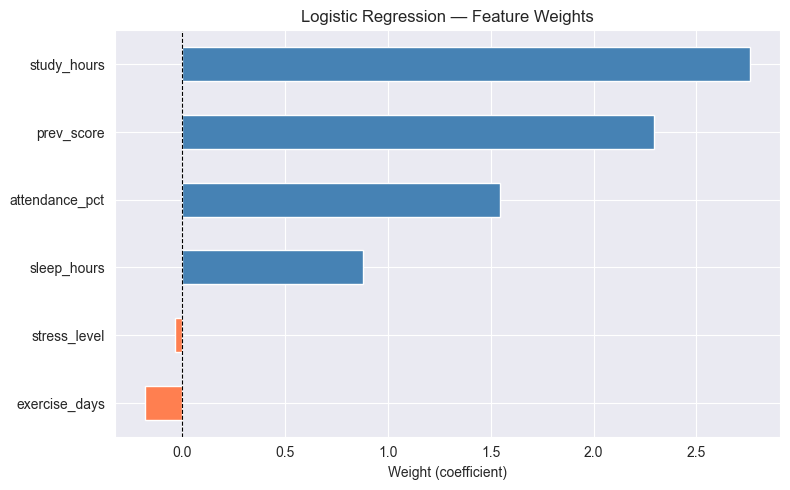

In [4]:
# Coefficients = weights learned for each feature
weights = pd.Series(
    lr.coef_[0],       # coef_ shape = (1, n_features) for binary
    index=feature_names
).sort_values()

print("Intercept (bias):", lr.intercept_[0])
print("\nFeature Weights:")
print(weights)

# Plot weights
colors = ['coral' if w < 0 else 'steelblue' for w in weights]

plt.figure(figsize=(8, 5))
weights.plot(kind='barh', color=colors)
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.title("Logistic Regression — Feature Weights")
plt.xlabel("Weight (coefficient)")
plt.tight_layout()
plt.show()

# Positive weight → feature increases P(Pass)
# Negative weight → feature decreases P(Pass)
# Larger absolute value → stronger influence

## Step 4 — ROC Curve and AUC

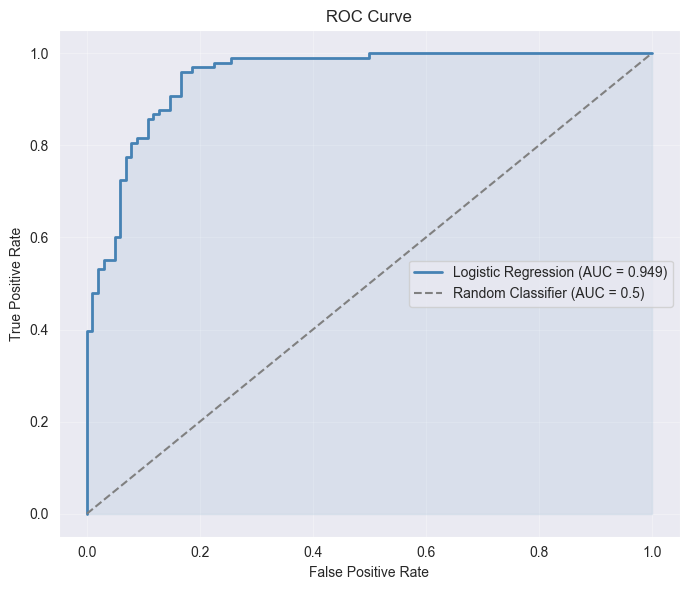

In [5]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2,
         label=f'Logistic Regression (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--',
         label='Random Classifier (AUC = 0.5)')
plt.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# AUC = 1.0 → perfect classifier
# AUC = 0.5 → random guessing
# AUC = 0.8+ → good model

## Step 5 — Changing the Decision Threshold

In [6]:
# Default threshold = 0.5
# But you can change it depending on the problem

thresholds_to_try = [0.3, 0.4, 0.5, 0.6, 0.7]

print(f"{'Threshold':>10} {'Accuracy':>10} {'Precision':>10} "
      f"{'Recall':>8} {'F1':>8}")
print("─" * 55)

from sklearn.metrics import precision_score, recall_score, f1_score

for thresh in thresholds_to_try:
    y_pred_thresh = (y_pred_prob >= thresh).astype(int)
    print(
        f"{thresh:>10.1f} "
        f"{accuracy_score(y_test, y_pred_thresh):>10.3f} "
        f"{precision_score(y_test, y_pred_thresh):>10.3f} "
        f"{recall_score(y_test, y_pred_thresh):>8.3f} "
        f"{f1_score(y_test, y_pred_thresh):>8.3f}"
    )

# Lower threshold → catches more positives (higher recall)
#                   but more false alarms (lower precision)
# Higher threshold → fewer false alarms (higher precision)
#                   but misses more positives (lower recall)
# Choose based on your problem:
#   Medical diagnosis → lower threshold (don't miss sick patients)
#   Spam filter       → higher threshold (don't block real emails)

 Threshold   Accuracy  Precision   Recall       F1
───────────────────────────────────────────────────────
       0.3      0.885      0.832    0.959    0.891
       0.4      0.880      0.856    0.908    0.881
       0.5      0.875      0.869    0.878    0.873
       0.6      0.855      0.879    0.816    0.847
       0.7      0.845      0.914    0.755    0.827


## Step 6 — Tune Regularization Strength

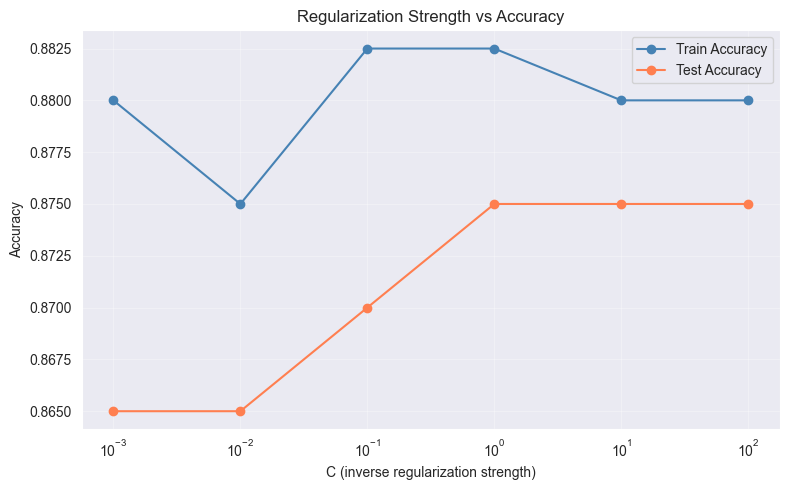

In [7]:
C_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
train_scores = []
test_scores  = []

for C in C_values:
    model = LogisticRegression(C=C, max_iter=1000, random_state=42)
    model.fit(X_train_scaled, y_train)
    train_scores.append(model.score(X_train_scaled, y_train))
    test_scores.append(model.score(X_test_scaled,  y_test))

plt.figure(figsize=(8, 5))
plt.semilogx(C_values, train_scores, marker='o',
             color='steelblue', label='Train Accuracy')
plt.semilogx(C_values, test_scores,  marker='o',
             color='coral',     label='Test Accuracy')
plt.xlabel("C (inverse regularization strength)")
plt.ylabel("Accuracy")
plt.title("Regularization Strength vs Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Very small C → underfitting  (too much regularization)
# Very large C → overfitting   (too little regularization)
# Sweet spot in the middle     → best generalization